# DATOS

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

ModuleNotFoundError: No module named 'scipy'

In [ ]:
# %pip install rpy2  <-- Descomentar si no está instalado para que el flujo Python-R funcione

In [ ]:
# Cargamos la extensión para habilitar celdas de R
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
#LECTURA DE DATOS E IMPRESIÓN DE LAS 5 PRIMERAS FILAS PARA ANALIZAR EL CONTENIDO DEL DATASET
df = pd.read_csv('cleaned_data.csv')
print(df.head())

   Unnamed: 0          Player    Ht     Wt     Colleges Pos  Age   Tm   G  GS  \
0           0  Alaa Abdelnaby  6-10  240.0         Duke  PF   22  POR  43   0   
1           1     Danny Ainge   6-4  175.0          BYU  SG   31  POR  80   0   
2           2     Mark Bryant   6-9  245.0   Seton Hall  PF   25  POR  53   0   
3           3    Wayne Cooper  6-10  220.0  New Orleans   C   34  POR  67   1   
4           4    Walter Davis   6-6  193.0          UNC  SG   36  POR  71  14   

   ...  Pts Max  Share                    Team   W   L   W/L%   GB   PS/G  \
0  ...      0.0    0.0  Portland Trail Blazers  63  19  0.768  0.0  114.7   
1  ...      0.0    0.0  Portland Trail Blazers  63  19  0.768  0.0  114.7   
2  ...      0.0    0.0  Portland Trail Blazers  63  19  0.768  0.0  114.7   
3  ...      0.0    0.0  Portland Trail Blazers  63  19  0.768  0.0  114.7   
4  ...      0.0    0.0  Portland Trail Blazers  63  19  0.768  0.0  114.7   

    PA/G   SRS  
0  106.0  8.47  
1  106.0  8.47  

# LIMPIEZA Y ANÁLISIS

In [ ]:
#NOMBRE DE TODAS LAS COLUMNAS DEL DATASET
print(df.columns.tolist())

['Unnamed: 0', 'Player', 'Ht', 'Wt', 'Colleges', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Year', 'Pts Won', 'Pts Max', 'Share', 'Team', 'W', 'L', 'W/L%', 'GB', 'PS/G', 'PA/G', 'SRS']


In [ ]:
#AJUSTE DEL NOMBRE DE LAS COLUMNAS
nuevas_cols=['Indice', 'Jugador', 'Altura', 'Peso', 'Universidad', 'Posicion', 'Edad', 'Equipo_Anterior', 'Partidos_Jugados', 'Partidos_Titular', 'Minutos_Jugados_PP',
             'Tiros_Anotados_PP', 'Tiros_Intentados_PP', 'Porcentaje_Tiros', 'Triples_Anotados_PP', 'Triples_Intentados_PP', 'Porcentaje_Triples', 'Dobles_Anotados_PP', 
             'Dobles_Intentados_PP', 'Porcentaje_Dobles', 'Porcentaje_Tiros_Efectivo', 'Tiros_Libres_Anotados', 'Tiros_Libres_Intentados', 'Porcentaje_Tiros_Libres',
             'Rebotes_Ofensivos_PP', 'Rebotes_Defensivos_PP', 'Rebotes_Totales_PP', 'Asistencias_PP', 'Robos_PP', 'Tapones_PP', 'Perdidas_PP', 'Faltas_Personales_PP', 'Puntos_PP', 'Temporada',
             'Puntos_MVP', 'Puntos_MVP_Obtenibles', 'Porcentaje_Puntos_MVP_Obtenidos', 'Equipo', 'Victorias', 'Derrotas', 'Porcentaje_V_D', 'Partidos_Atras', 'Puntos_Equipo_PP', 
             'Puntos_Rivales_PP', 'SRS']

df.columns=nuevas_cols
print(df.head())

   Indice         Jugador Altura   Peso  Universidad Posicion  Edad  \
0       0  Alaa Abdelnaby   6-10  240.0         Duke       PF    22   
1       1     Danny Ainge    6-4  175.0          BYU       SG    31   
2       2     Mark Bryant    6-9  245.0   Seton Hall       PF    25   
3       3    Wayne Cooper   6-10  220.0  New Orleans        C    34   
4       4    Walter Davis    6-6  193.0          UNC       SG    36   

  Equipo_Anterior  Partidos_Jugados  Partidos_Titular  ...  \
0             POR                43                 0  ...   
1             POR                80                 0  ...   
2             POR                53                 0  ...   
3             POR                67                 1  ...   
4             POR                71                14  ...   

   Puntos_MVP_Obtenibles  Porcentaje_Puntos_MVP_Obtenidos  \
0                    0.0                              0.0   
1                    0.0                              0.0   
2                

In [ ]:
#NÚMERO DE ENTRADAS NO NULAS, TIPO DE LOS DATOS DE CADA COLUMNA
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17976 entries, 0 to 17975
Data columns (total 45 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Indice                           17976 non-null  int64  
 1   Jugador                          17976 non-null  str    
 2   Altura                           17976 non-null  str    
 3   Peso                             17976 non-null  float64
 4   Universidad                      17976 non-null  str    
 5   Posicion                         17976 non-null  str    
 6   Edad                             17976 non-null  int64  
 7   Equipo_Anterior                  17976 non-null  str    
 8   Partidos_Jugados                 17976 non-null  int64  
 9   Partidos_Titular                 17976 non-null  int64  
 10  Minutos_Jugados_PP               17976 non-null  float64
 11  Tiros_Anotados_PP                17976 non-null  float64
 12  Tiros_Intentados_PP          

In [ ]:
#ELIMINAR COLUMNA ÍNDICE
df = df.drop('Indice', axis=1)
print(df.head())

          Jugador Altura   Peso  Universidad Posicion  Edad Equipo_Anterior  \
0  Alaa Abdelnaby   6-10  240.0         Duke       PF    22             POR   
1     Danny Ainge    6-4  175.0          BYU       SG    31             POR   
2     Mark Bryant    6-9  245.0   Seton Hall       PF    25             POR   
3    Wayne Cooper   6-10  220.0  New Orleans        C    34             POR   
4    Walter Davis    6-6  193.0          UNC       SG    36             POR   

   Partidos_Jugados  Partidos_Titular  Minutos_Jugados_PP  ...  \
0                43                 0                 6.7  ...   
1                80                 0                21.4  ...   
2                53                 0                14.7  ...   
3                67                 1                11.1  ...   
4                71                14                20.9  ...   

   Puntos_MVP_Obtenibles  Porcentaje_Puntos_MVP_Obtenidos  \
0                    0.0                              0.0   
1     

In [ ]:
# eliminamos columnas que no son relevantes
cols_eliminar= [
            'Tiros_Anotados_PP', 'Tiros_Intentados_PP', 'Triples_Anotados_PP', 'Triples_Intentados_PP', 'Dobles_Anotados_PP', 
             'Dobles_Intentados_PP', 'Tiros_Libres_Anotados', 'Tiros_Libres_Intentados',
             'Rebotes_Ofensivos_PP', 'Rebotes_Defensivos_PP', 
             'Puntos_MVP', 'Puntos_MVP_Obtenibles']
df=df.drop(columns=cols_eliminar)

In [ ]:
#VEMOS CUÁNTOS DATOS FALTAN EN CADA COLUMNA
print(df.isnull().sum())

Jugador                            0
Altura                             0
Peso                               0
Universidad                        0
Posicion                           0
Edad                               0
Equipo_Anterior                    0
Partidos_Jugados                   0
Partidos_Titular                   0
Minutos_Jugados_PP                 0
Porcentaje_Tiros                   0
Porcentaje_Triples                 0
Porcentaje_Dobles                  0
Porcentaje_Tiros_Efectivo          0
Porcentaje_Tiros_Libres            0
Rebotes_Totales_PP                 0
Asistencias_PP                     0
Robos_PP                           0
Tapones_PP                         0
Perdidas_PP                        0
Faltas_Personales_PP               0
Puntos_PP                          0
Temporada                          0
Porcentaje_Puntos_MVP_Obtenidos    0
Equipo                             0
Victorias                          0
Derrotas                           0
P

In [ ]:
# Se observa que la columa 'Altura' no es de escala númerica, sino que tiene un formato de texto con pies y pulgadas. Para convertir esta columna a centímetros, se puede crear una función que realice esta conversión.
# También se observa que la columna 'Peso' está en libras, por lo que la convertimos a kilogramos.

def cambio_a_cm(h):
    try:
        pies, cm = map(int, h.split('-'))
        return (pies * 30.48) + (cm * 2.54)
    except:
        return None 

df['Altura'] = df['Altura'].apply(cambio_a_cm)
df['Peso'] = df['Peso'] * 0.453592

df.rename(columns={'Altura': 'Altura_cm', 'Peso': 'Peso_kg'}, inplace=True)

print(df[['Altura_cm', 'Peso_kg']].dtypes)
print(df.head())


Altura_cm    float64
Peso_kg      float64
dtype: object
          Jugador  Altura_cm     Peso_kg  Universidad Posicion  Edad  \
0  Alaa Abdelnaby     208.28  108.862080         Duke       PF    22   
1     Danny Ainge     193.04   79.378600          BYU       SG    31   
2     Mark Bryant     205.74  111.130040   Seton Hall       PF    25   
3    Wayne Cooper     208.28   99.790240  New Orleans        C    34   
4    Walter Davis     198.12   87.543256          UNC       SG    36   

  Equipo_Anterior  Partidos_Jugados  Partidos_Titular  Minutos_Jugados_PP  \
0             POR                43                 0                 6.7   
1             POR                80                 0                21.4   
2             POR                53                 0                14.7   
3             POR                67                 1                11.1   
4             POR                71                14                20.9   

   ...  Temporada  Porcentaje_Puntos_MVP_Obtenid

In [ ]:
# vamos a distinguir entre variables cualitativas y cuantitativas

# Con este codigo conseguimos que s emuestren todas las columnas de la base de datos y sus tipos de datos, sin que se corte la visualización por el número de filas.
resumen_tipos = pd.DataFrame({
    'Variable': df.dtypes.index,
    'Tipo_Dato': df.dtypes.values
})

# Para que te deje ver las 44 filas en el notebook sin cortes:
with pd.option_context('display.max_rows', None):
    display(resumen_tipos)

,Variable,Tipo_Dato
0,Jugador,str
1,Altura_cm,float64
2,Peso_kg,float64
3,Universidad,str
4,Posicion,str
5,Edad,int64
6,Equipo_Anterior,str
7,Partidos_Jugados,int64
8,Partidos_Titular,int64
9,Minutos_Jugados_PP,float64


In [ ]:
# lista de todas las categorías 
print(df['Posicion'].unique())

<ArrowStringArray>
[   'PF',    'SG',     'C',    'SF',    'PG',  'PF-C', 'PG-SG', 'SG-PG',
 'SG-SF', 'SF-SG', 'PF-SF', 'SF-PF',  'C-PF', 'SG-PF',  'SF-C', 'PG-SF']
Length: 16, dtype: str


In [ ]:
# Como tenemos posiciones híbridas, vamos a crear una nueva columna en la que guardemos la posicion principal de cada jugador para poder hacer un mejor análisis
# Creamos una columna nueva simplificada

df['Posicion_Principal'] = df['Posicion'].apply(lambda x: x.split('-')[0])

print(df['Posicion_Principal'].value_counts()) # tenemos mas o menos el mismo numero de jugadores por posicion, lo que es bueno para el análisis porque no va a haber un sesgo por tener mas jugadores de una posicion que de otra

Posicion_Principal
PF    3753
C     3658
SG    3642
PG    3470
SF    3453
Name: count, dtype: int64


In [ ]:
# Seleccionamos variables de interés para el análisis de correlación
df_corr = df[['Puntos_PP', 'Asistencias_PP', 'Rebotes_Totales_PP', 'Minutos_Jugados_PP', 'Edad']]

# Enviamos a R
%R -i df_corr

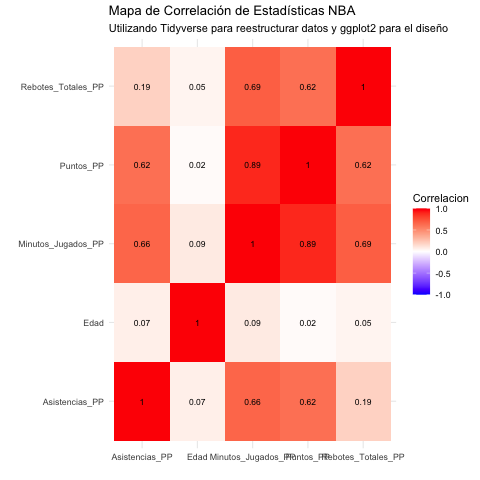

In [ ]:
%%R # <- Esto indica que el código que sigue es código R, no Python
# Mapa de calor

library(tidyverse)

cor_matrix <- cor(df_corr, use = "complete.obs") %>%
  as.data.frame() %>%
  rownames_to_column(var = "Variable1") %>%
  pivot_longer(cols = -Variable1, names_to = "Variable2", values_to = "Correlacion")

ggplot(cor_matrix, aes(x = Variable1, y = Variable2, fill = Correlacion)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", limit = c(-1,1)) +
  theme_minimal() +
  labs(title = "Mapa de Correlación de Estadísticas NBA",
       subtitle = "Utilizando Tidyverse para reestructurar datos y ggplot2 para el diseño",
       x = "", y = "") +
  geom_text(aes(label = round(Correlacion, 2)), size = 3) 

In [ ]:
# Puntos vs Minutos Jugados (0.89): Es la correlación más fuerte del dataset. Esto confirma que en la NBA, el volumen de anotación depende directamente del tiempo jugado. Esto nos indica que podemos crear una columna "Rol" basada en los minutos.

# Minutos Jugados vs Asistencias (0.66) y Rebotes (0.69): Hay una relación positiva considerable. Indica que los jugadores con más tiempo no solo anotan, sino que contribuyen en todas las facetas del juego.

# Edad (Baja correlación): Esto indica que la edad no es un factor determinante para anotar puntos o dar asistencias, el talento y los minutos importan más que la veteranía.

In [ ]:
# Definir el rol de cada jugador en función de los minutos jugados por partido, podemos crear una función que clasifique a los jugadores en diferentes categorías ("Estrella", "Titular", "Rotación", "Banquillo"). Luego, aplicamos esta función a la columna 'Minutos_Jugados_PP' para crear una nueva columna 'Rol'.

def definir_rol(minutos):
    if minutos > 30:
        return 'Estrella'
    elif minutos > 20:
        return 'Titular'
    elif minutos > 10:
        return 'Rotación'
    else:
        return 'Banquillo'

df['Rol'] = df['Minutos_Jugados_PP'].apply(definir_rol)

In [ ]:
# Pasamos el DataFrame 'df' de Python al entorno de R
%R -i df

In [ ]:
%%R
# Como hemos añadido la columna 'Rol' a nuestro DataFrame, ahora podemos usarla para hacer un análisis descriptivo agrupado por el rol de cada jugador. Esto nos permitirá entender mejor cómo varían las estadísticas clave según el rol que desempeñan en su equipo y ver si existe algun problema en como se distribuyen los datos
# ¿Cuál es el promedio de puntos, rebotes y asistencias por cada "Rol" de jugador?

library(tidyverse)

resumen_nba <- df %>%
  group_by(Rol) %>%
  summarise(
    Total_Jugadores = n(),
    Promedio_Puntos = mean(Puntos_PP, na.rm = TRUE),
    Promedio_Asistencias = mean(Asistencias_PP, na.rm = TRUE),
    Promedio_Rebotes = mean(Rebotes_Totales_PP, na.rm = TRUE)
  ) %>%
  arrange(desc(Promedio_Puntos))

print(resumen_nba)

# A tibble: 4 × 5
  Rol      Total_Jugadores Promedio_Puntos Promedio_Asistencias Promedio_Rebotes
  <chr>              <int>           <dbl>                <dbl>            <dbl>
1 Estrella            4011           17.0                 3.86              6.14
2 Titular             4936            9.76                2.20              4.33
3 Rotación            5684            5.05                1.17              2.62
4 Banquil…            3345            2.07                0.444             1.20


`geom_smooth()` using formula = 'y ~ x'


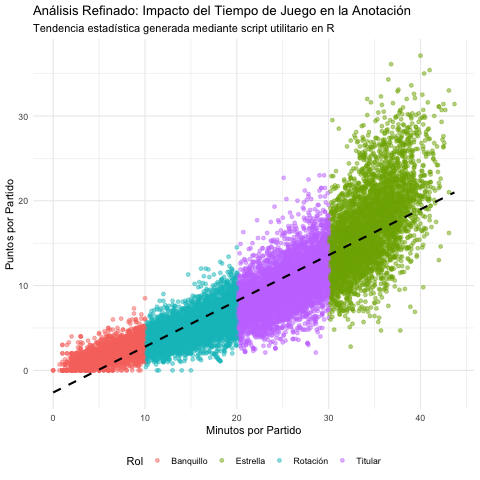

In [ ]:
%%R
library(ggplot2)

ggplot(df, aes(x = Minutos_Jugados_PP, y = Puntos_PP, color = Rol)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", se = FALSE, linetype = "dashed", color = "black") +
  theme_minimal() +
  labs(title = "Análisis Refinado: Impacto del Tiempo de Juego en la Anotación",
       subtitle = "Tendencia estadística generada mediante script utilitario en R",
       x = "Minutos por Partido",
       y = "Puntos por Partido") +
  theme(legend.position = "bottom")

In [ ]:
# Relación Lineal Clara: La línea de puntos discontinua muestra una tendencia ascendente muy marcada. Esto nos indica que, a medida que aumentan los minutos por partido, los puntos anotados crecen de forma proporcional.

# El gráfico justifica visualmente la creación de tu variable "Rol". Se observa cómo los colores están perfectamente agrupados por bloques en el eje X

# Nos fijamos que en el grupo de las "Estrellas" (verde), la dispersión es mayor. Hay jugadores que jugando los mismos minutos pueden anotar desde 15 hasta más de 30 puntos. Esto indica que en la élite, la eficiencia importa tanto como el tiempo en pista.

In [ ]:
%%R

# 5 mejores "Anotadores" que además sean del rol "Estrella"

top_estrellas <- df %>%
  filter(Rol == "Estrella") %>%
  select(Jugador, Equipo, Puntos_PP) %>%
  slice_max(Puntos_PP, n = 5)

print(top_estrellas)

             Jugador             Equipo Puntos_PP
9931  Michael Jordan      Chicago Bulls      37.1
6623    James Harden    Houston Rockets      36.1
15457    Kobe Bryant Los Angeles Lakers      35.4
15504 Michael Jordan      Chicago Bulls      35.0
5960    James Harden    Houston Rockets      34.3


In [ ]:
# separamos las variables
vars_cuant = ['Altura_cm', 'Peso_kg', 'Edad', 'Partidos_Jugados', 'Partidos_Titular', 'Minutos_Jugados_PP',
             'Porcentaje_Tiros', 'Porcentaje_Triples', 'Porcentaje_Dobles', 'Porcentaje_Tiros_Efectivo', 'Porcentaje_Tiros_Libres',
             'Rebotes_Totales_PP', 'Asistencias_PP', 'Robos_PP', 'Tapones_PP', 'Perdidas_PP', 'Faltas_Personales_PP', 'Puntos_PP', 'Temporada',
             'Porcentaje_Puntos_MVP_Obtenidos', 'Victorias', 'Derrotas', 'Porcentaje_V_D', 'Partidos_Atras', 'Puntos_Equipo_PP', 
             'Puntos_Rivales_PP', 'SRS']
vars_cuali = ['Universidad', 'Posicion', 'Equipo_Anterior', 'Equipo', 'Rol']

# Análisis variables cuantitativas

In [ ]:
analisis_cuant = pd.DataFrame(index=['Media', 'Mediana', 'Moda', 'Rango', 'Varianza', 
                                     'Desviación Estándar', 'Asimetría', 'Curtosis'])

for col in vars_cuant:
    analisis_cuant[col] = [
        df[col].mean(),
        df[col].median(),
        df[col].mode()[0], # La moda puede devolver varios valores, tomamos el primero
        df[col].max() - df[col].min(),
        df[col].var(),
        df[col].std(),
        df[col].skew(),
        df[col].kurtosis()
    ]

display(analisis_cuant.round(2))

,Altura_cm,Peso_kg,Edad,Partidos_Jugados,Partidos_Titular,Minutos_Jugados_PP,Porcentaje_Tiros,Porcentaje_Triples,Porcentaje_Dobles,Porcentaje_Tiros_Efectivo,...,Puntos_PP,Temporada,Porcentaje_Puntos_MVP_Obtenidos,Victorias,Derrotas,Porcentaje_V_D,Partidos_Atras,Puntos_Equipo_PP,Puntos_Rivales_PP,SRS
Media,200.27,97.92,26.68,54.06,27.30,20.50,0.44,0.22,0.46,0.47,...,8.46,2002.28,0.01,39.73,40.40,0.50,15.84,102.35,102.49,-0.13
Mediana,200.66,97.52,26.00,62.00,12.00,20.00,0.45,0.26,0.47,0.48,...,6.90,2003.00,0.00,41.00,40.00,0.51,14.00,101.80,102.50,-0.01
Moda,205.74,99.79,23.00,82.00,0.00,9.00,0.50,0.00,0.50,0.50,...,2.00,2018.00,0.00,41.00,41.00,0.50,0.00,106.60,104.70,-0.07
Rango,71.12,102.97,26.00,84.00,84.00,43.70,1.00,1.00,1.00,1.50,...,37.10,41.00,1.00,66.00,63.00,0.78,56.00,44.60,47.40,26.48
Varianza,86.42,153.22,16.72,637.76,898.53,102.03,0.01,0.03,0.01,0.01,...,37.27,140.90,0.00,164.26,163.42,0.02,170.23,52.74,53.32,20.36
Desviación Estándar,9.30,12.38,4.09,25.25,29.98,10.10,0.09,0.18,0.10,0.10,...,6.11,11.87,0.06,12.82,12.78,0.15,13.05,7.26,7.30,4.51
Asimetría,-0.31,0.25,0.60,-0.67,0.69,0.10,-0.79,0.46,-1.05,-0.95,...,1.00,-0.15,12.29,-0.11,0.19,-0.16,0.52,0.21,0.11,-0.20
Curtosis,-0.02,0.05,-0.10,-0.86,-1.14,-1.08,8.62,0.93,8.79,12.19,...,0.60,-1.13,164.61,-0.74,-0.70,-0.74,-0.65,-0.48,-0.27,-0.44


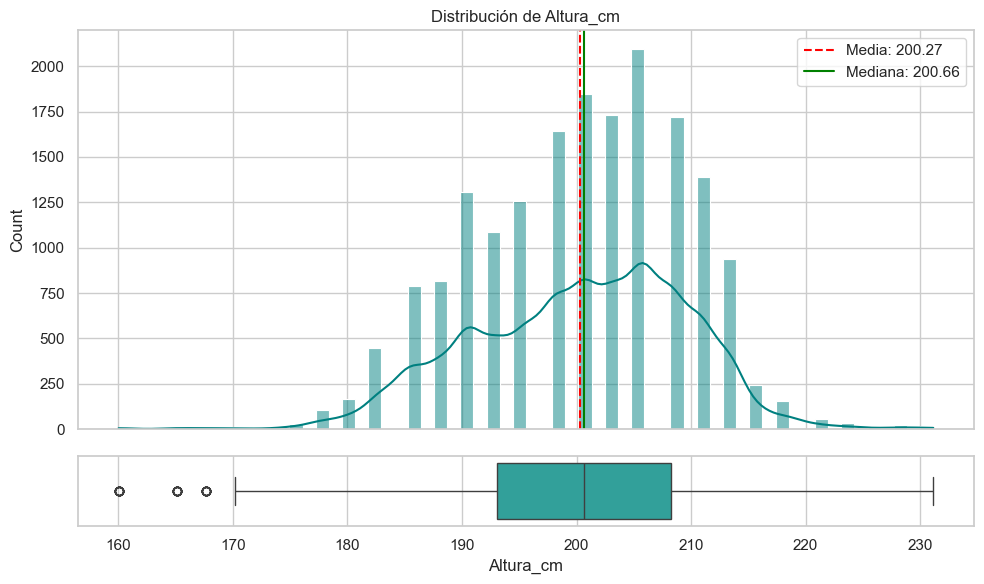

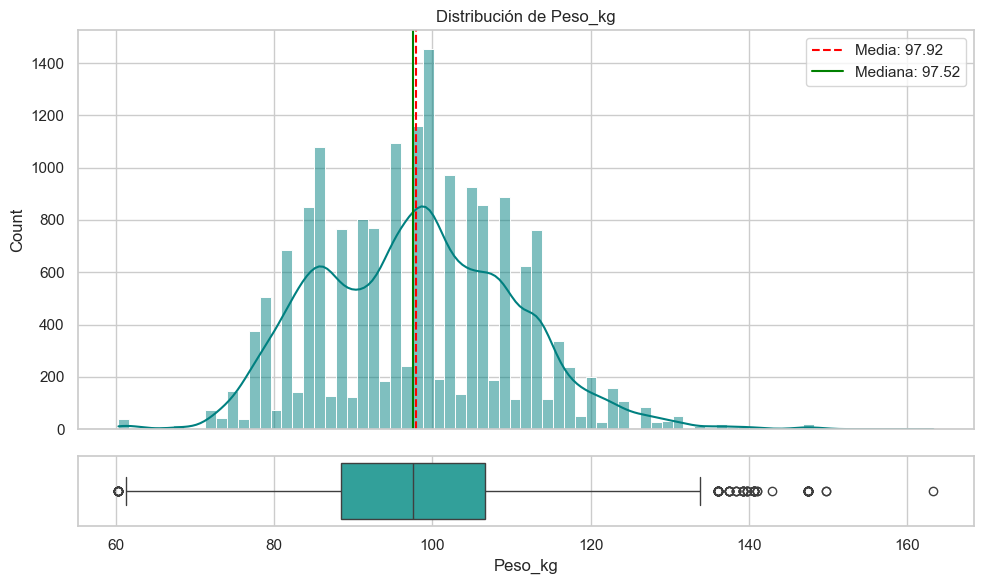

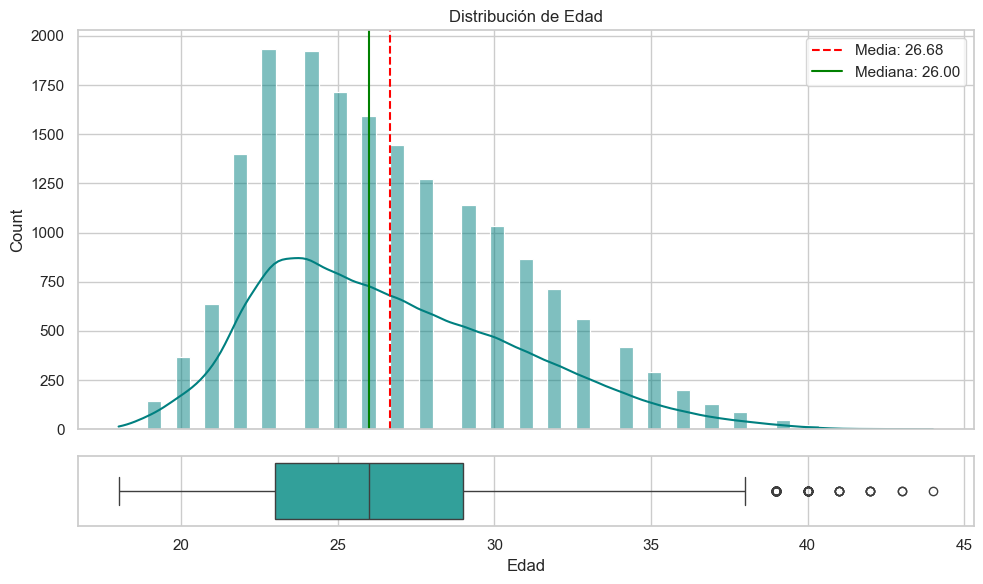

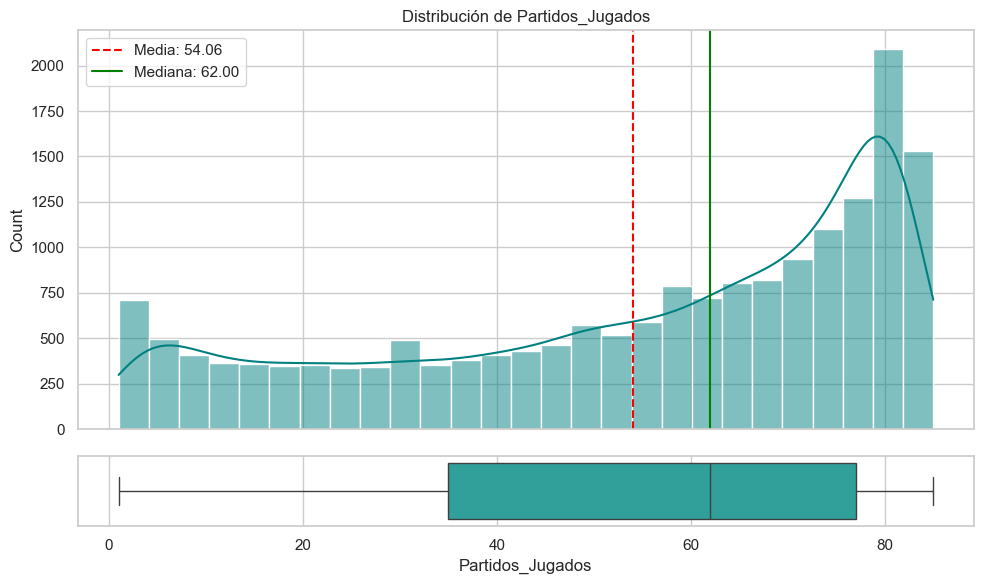

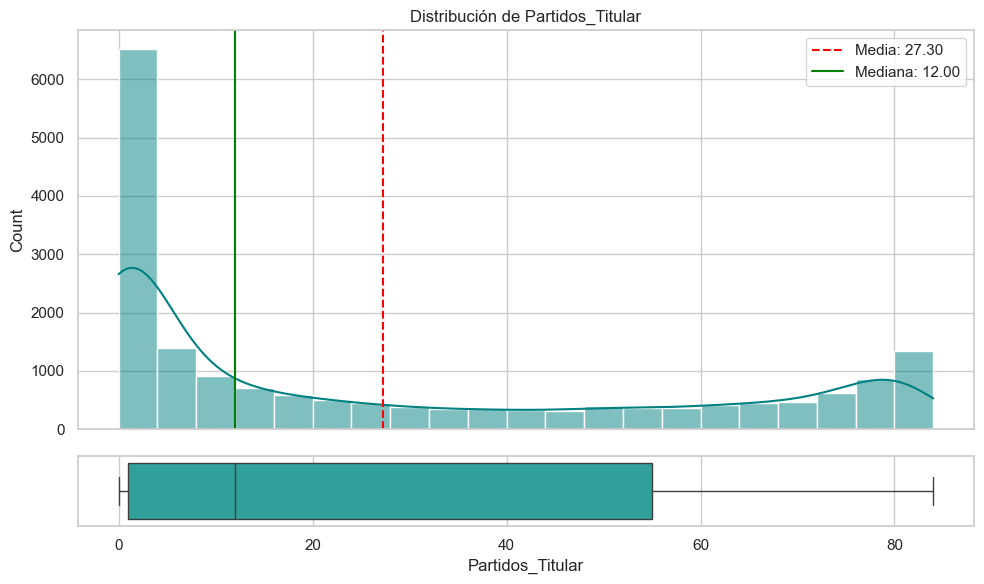

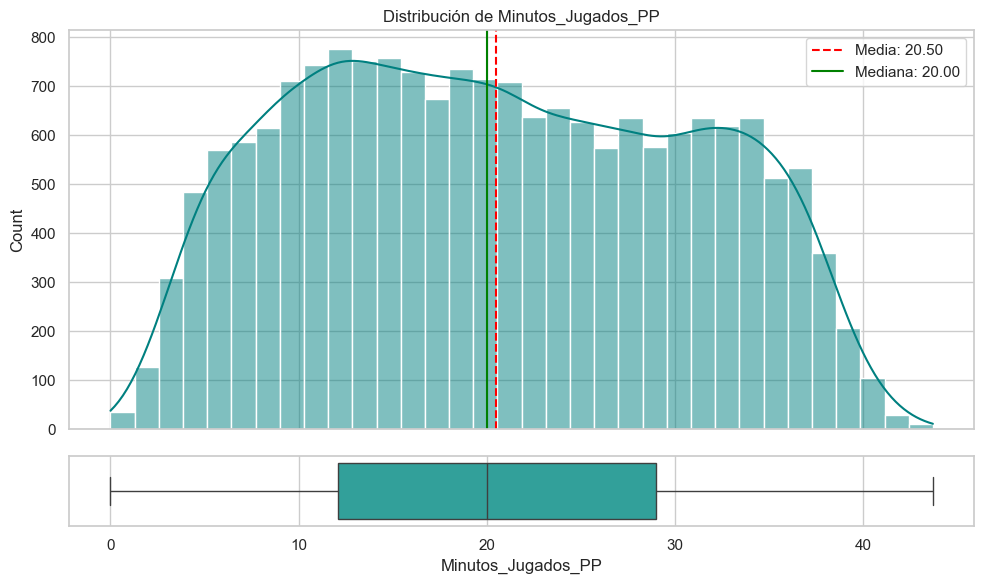

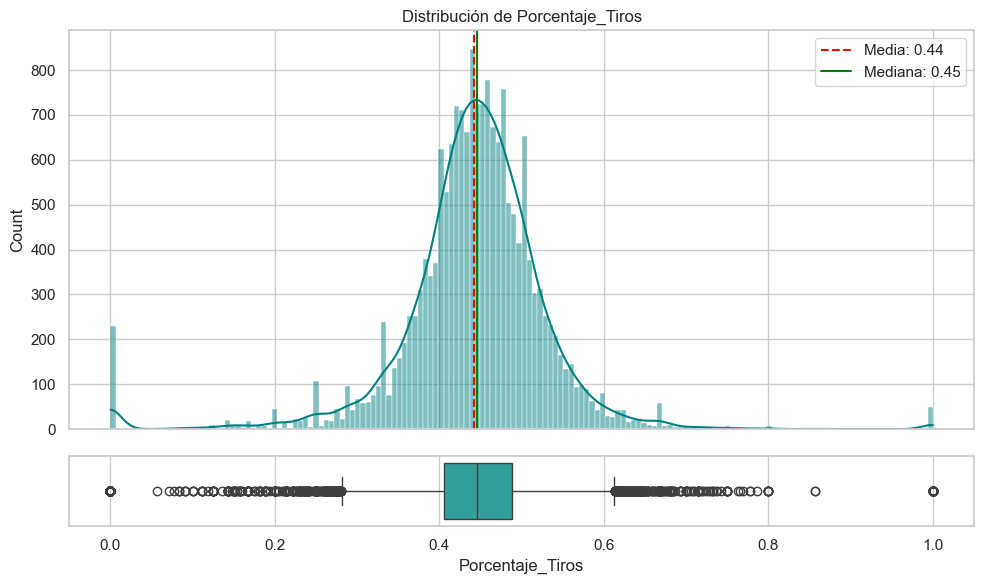

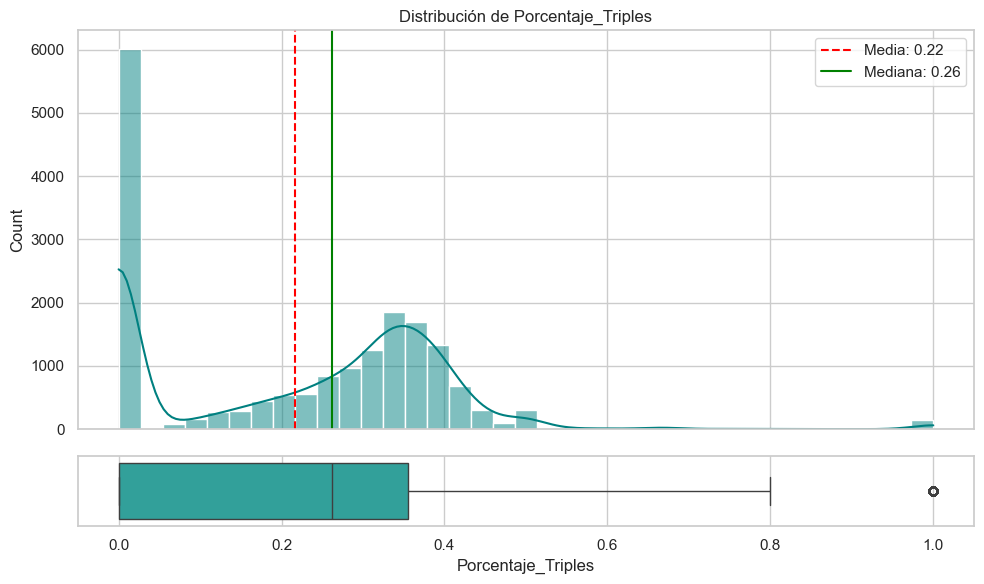

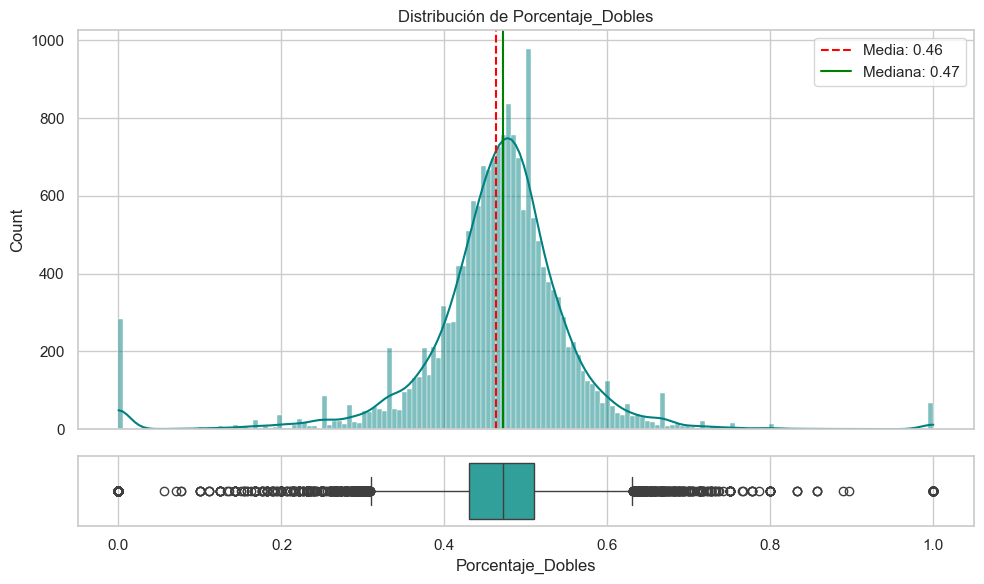

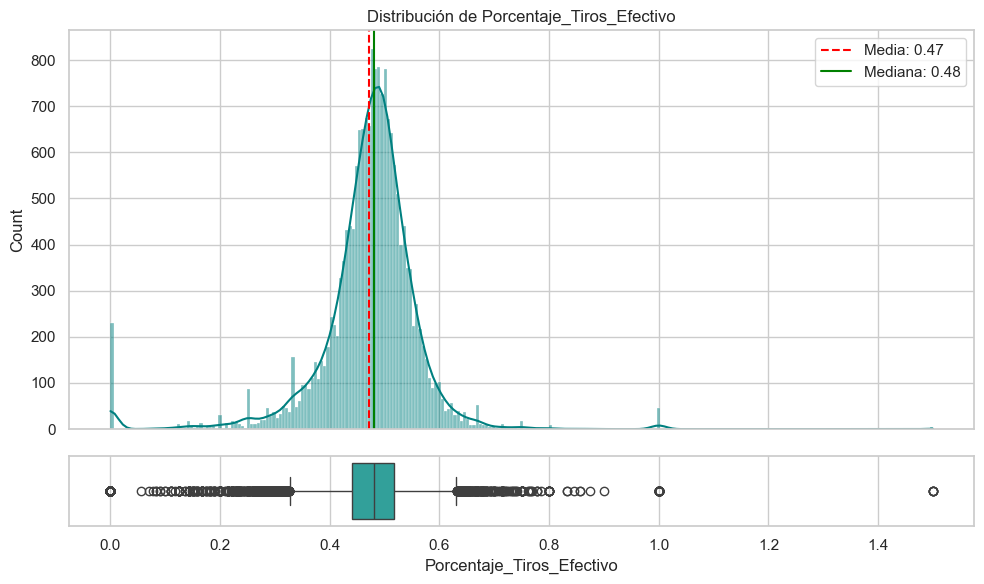

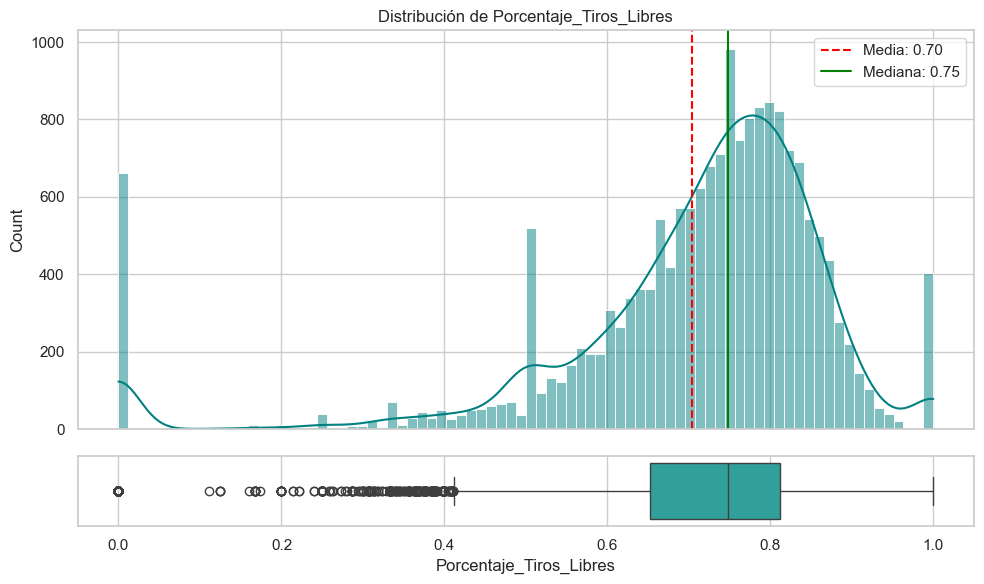

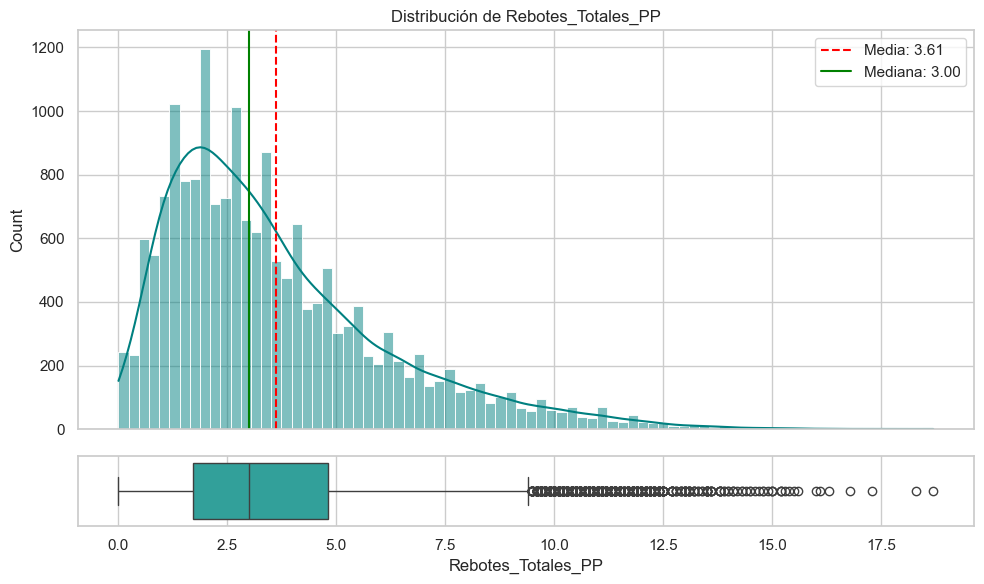

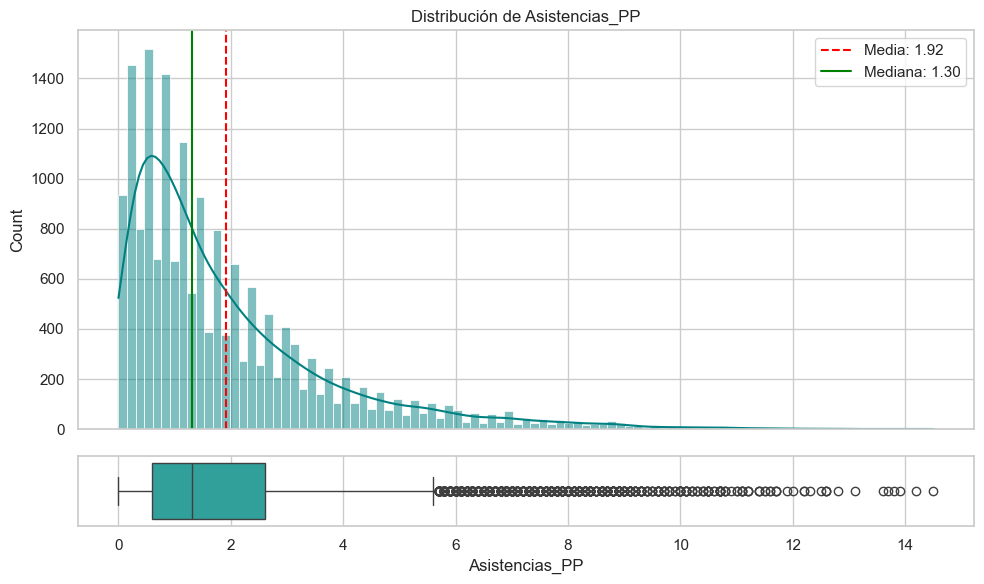

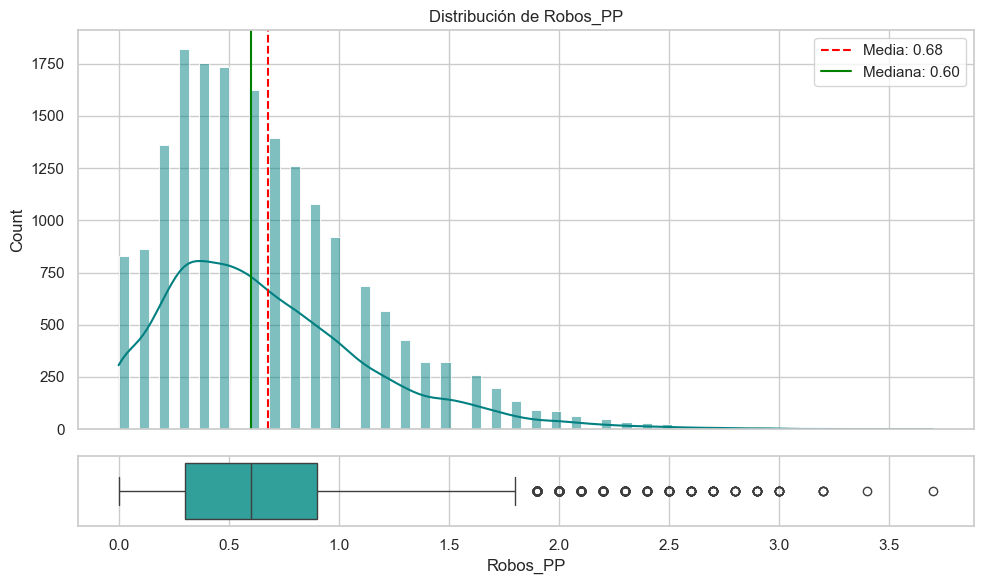

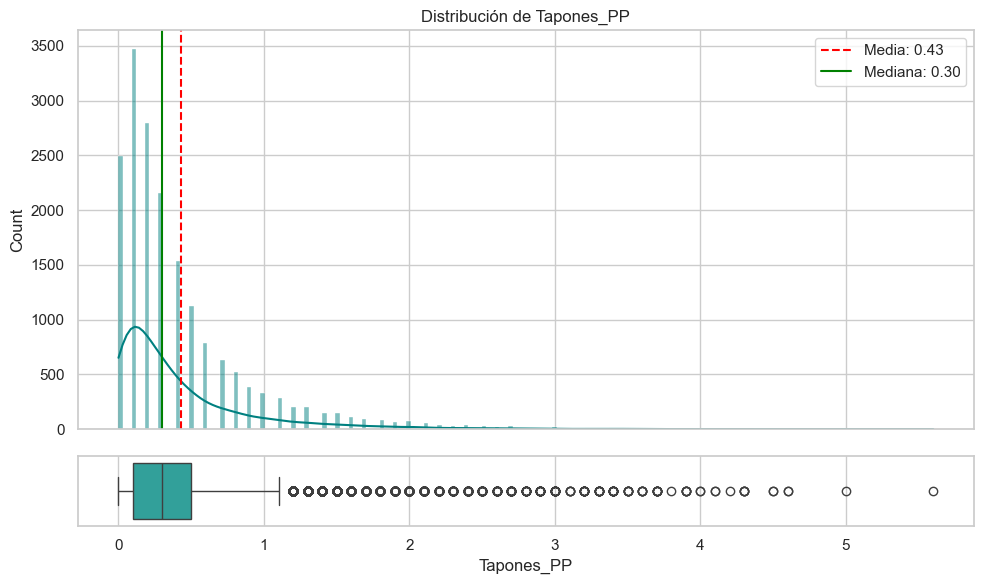

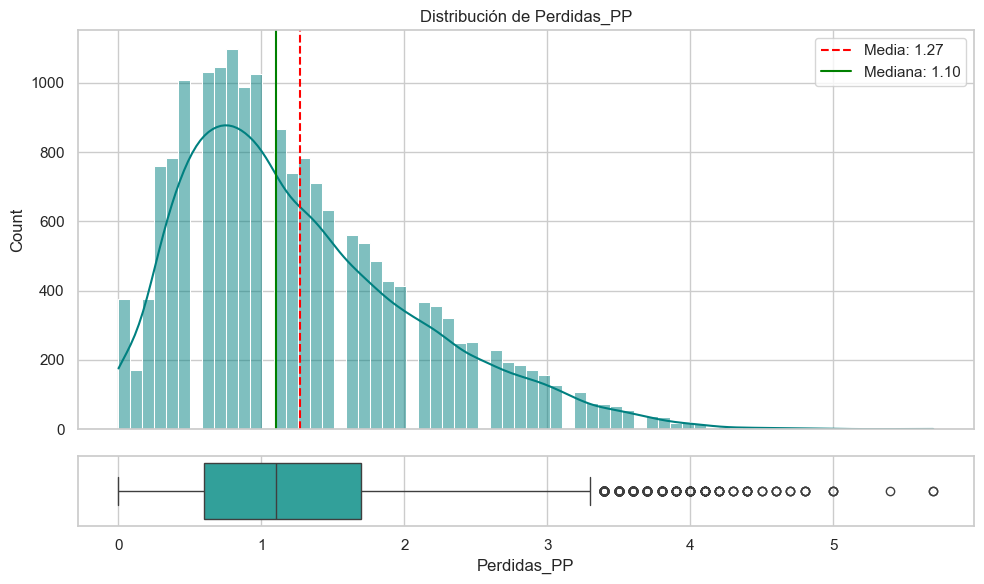

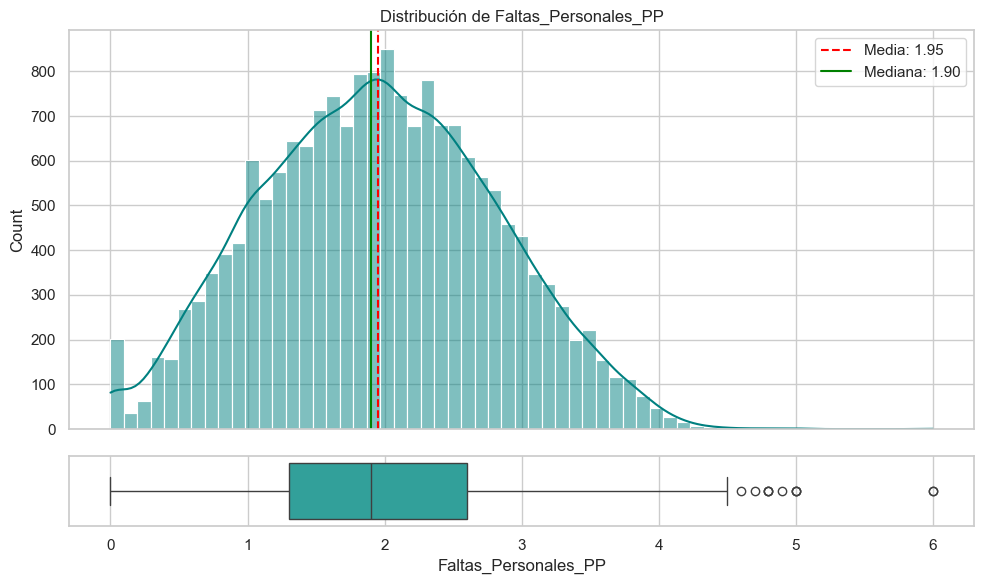

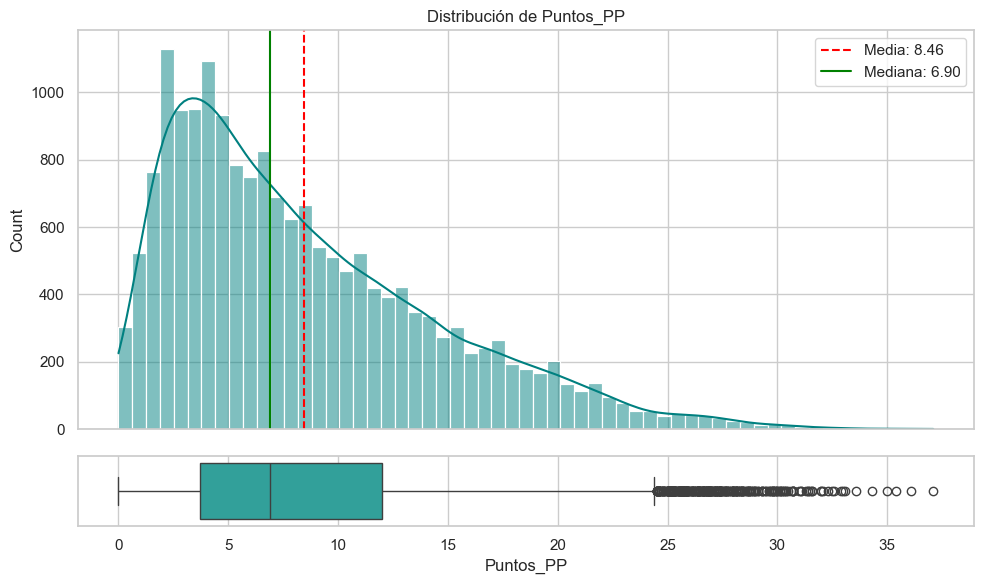

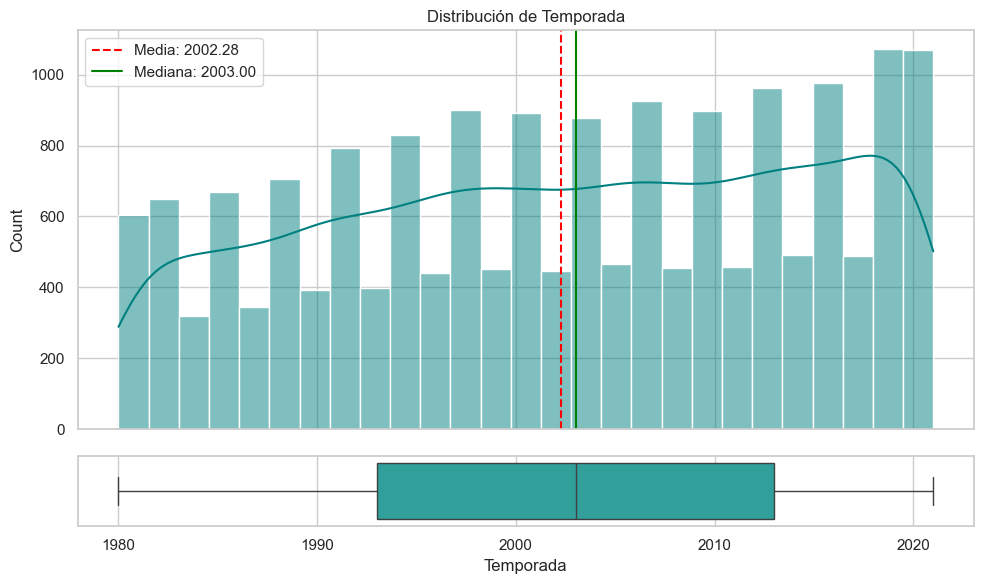

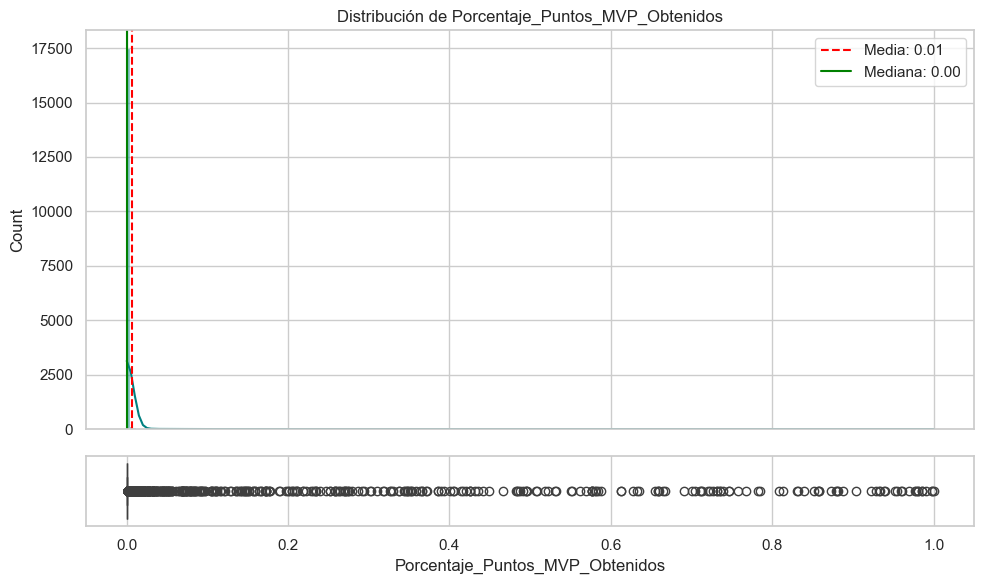

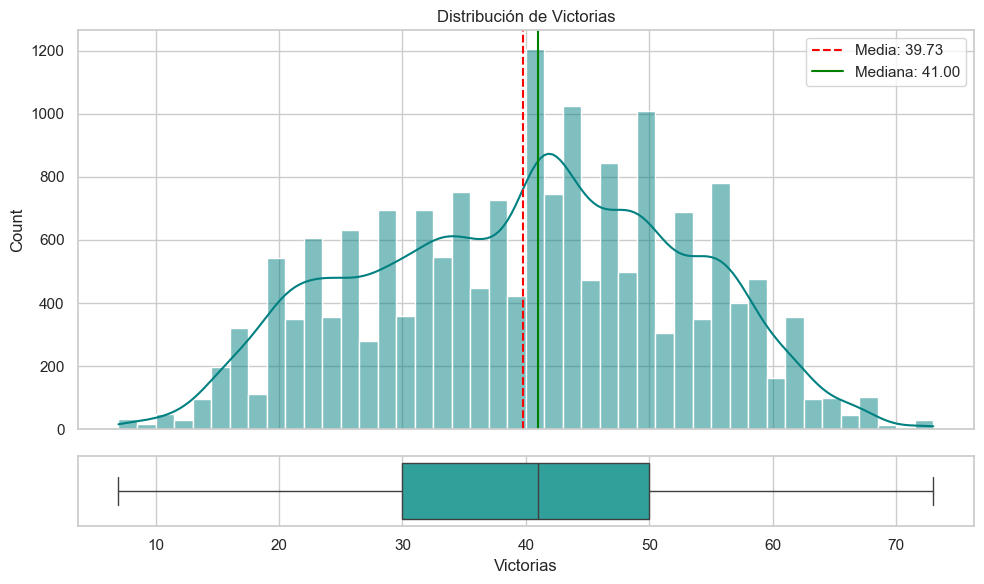

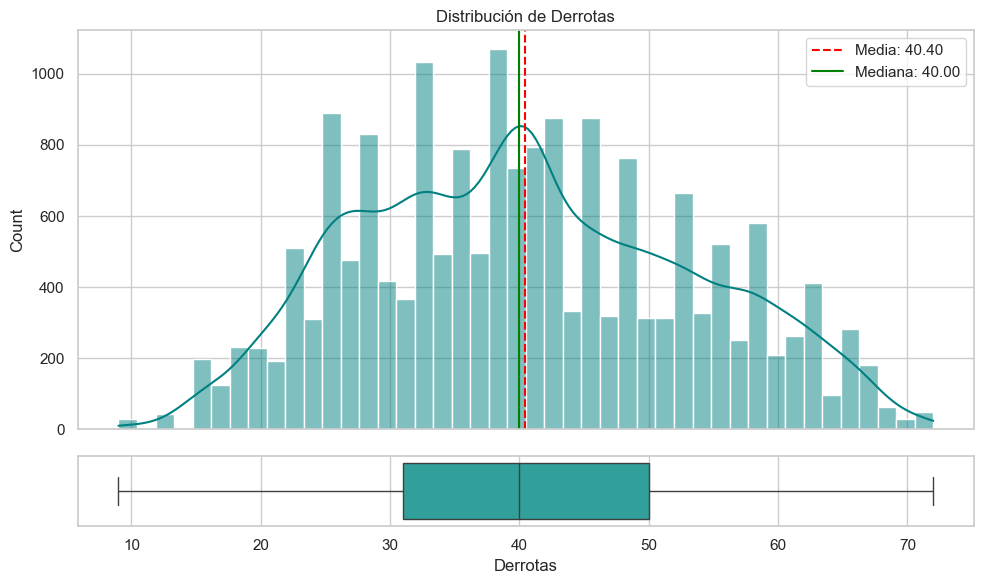

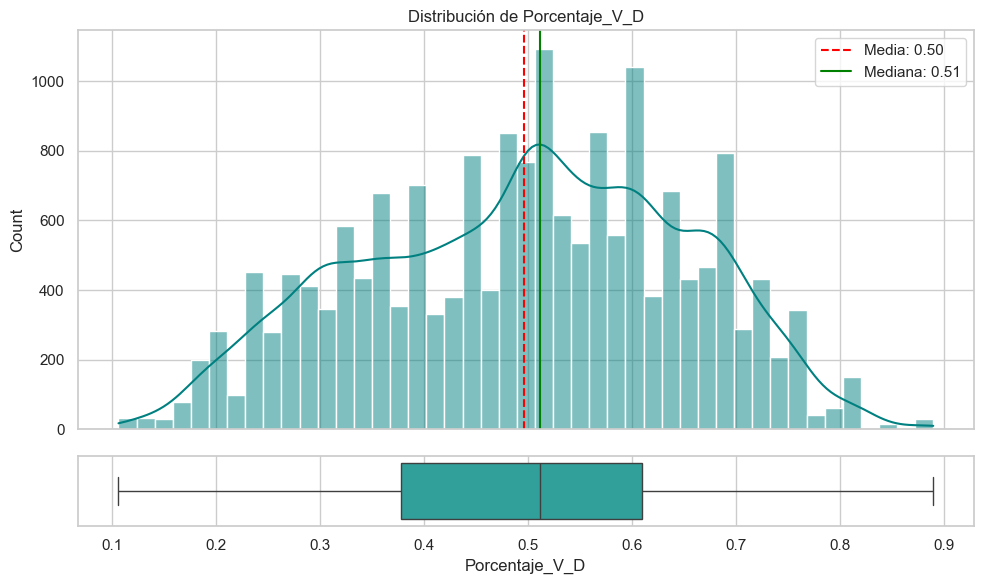

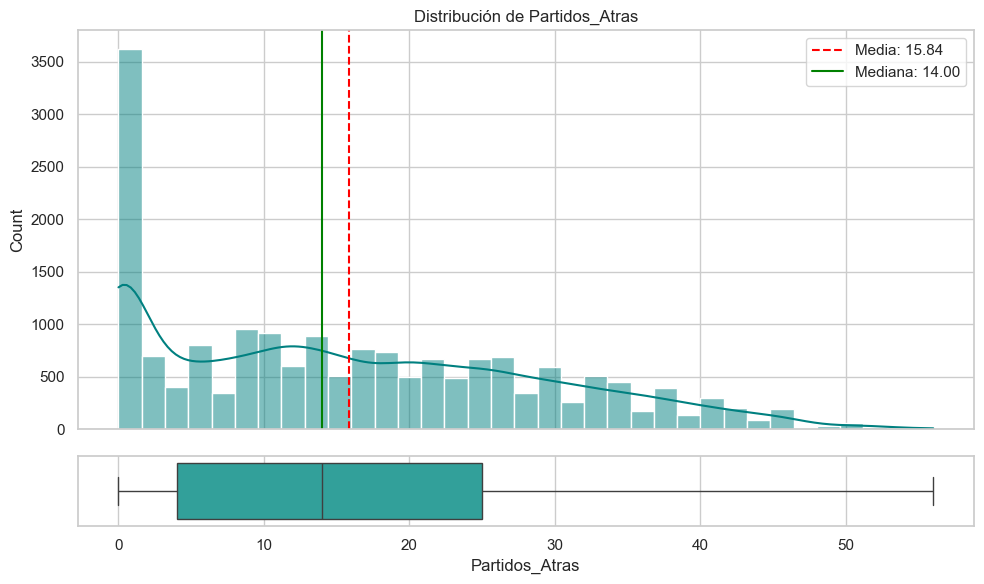

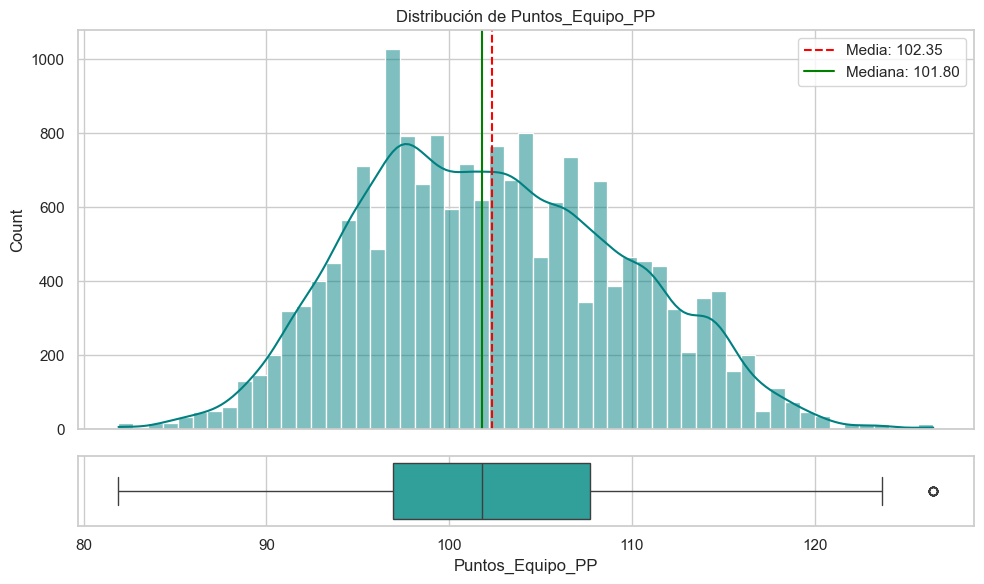

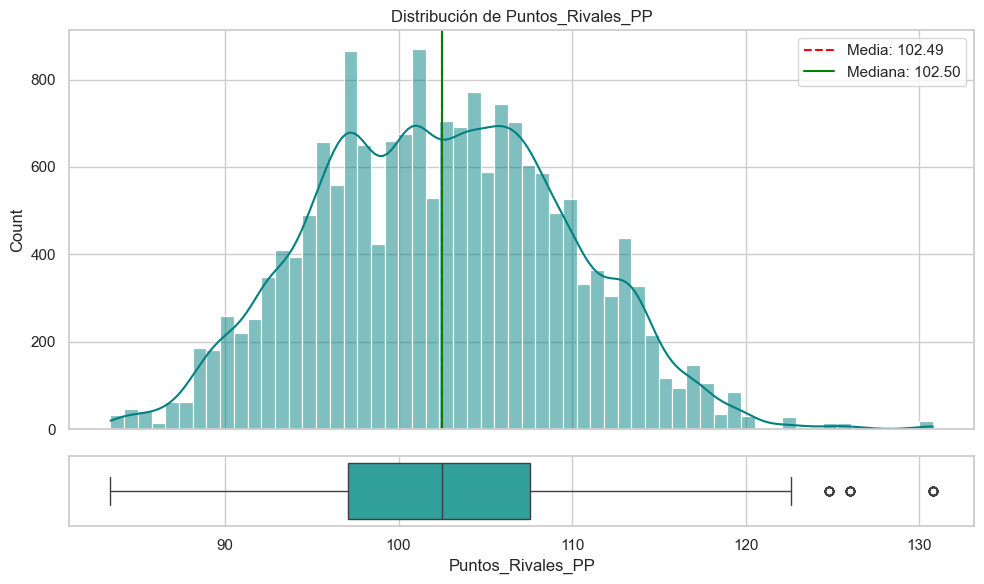

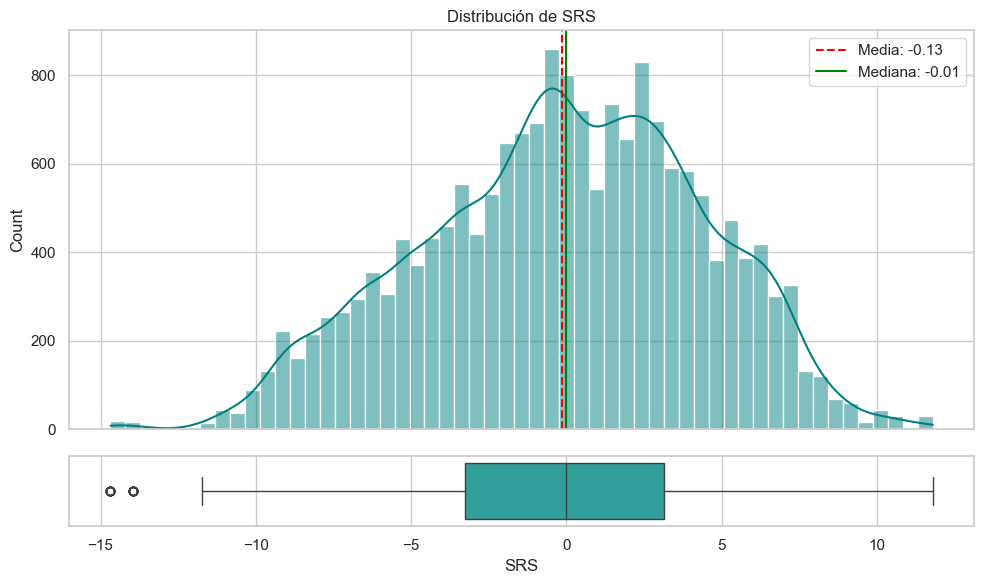

In [ ]:
# Configuramos el estilo
sns.set_theme(style="whitegrid")

for col in vars_cuant:
    fig, (ax_hist, ax_box) = plt.subplots(2, sharex=True, 
                                          gridspec_kw={"height_ratios": (.85, .15)}, 
                                          figsize=(10, 6))
    
    # Histograma con KDE (curva de densidad)
    sns.histplot(data=df, x=col, kde=True, ax=ax_hist, color="teal")
    ax_hist.axvline(df[col].mean(), color='red', linestyle='--', label=f'Media: {df[col].mean():.2f}')
    ax_hist.axvline(df[col].median(), color='green', linestyle='-', label=f'Mediana: {df[col].median():.2f}')
    ax_hist.set_title(f'Distribución de {col}')
    ax_hist.legend()
    
    # Boxplot
    sns.boxplot(data=df, x=col, ax=ax_box, color="lightseagreen")
    ax_box.set(xlabel=col)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Observamos en el gráfico de la variable Porcentaje_Puntos_MVP_Obtenidos que la gran mayoría de jugadores no recibe prácticamente votos MVP y que un pequeño grupo de jugadores acumula casi todos los pntos MVP.
# Por tanto, la media no es representativa para el conjunto de datos y la distribución del porcentaje de puntos MVP obtenidos presenta una fuerte asimetría positiva, con la mayoría de los jugadores concentrando valores cercanos a cero.
# Entonces, prescindimos de esta variable ya que no va aser significativa para nuestro problema
df = df.drop('Porcentaje_Puntos_MVP_Obtenidos', axis=1)
df.to_csv('cleaned_data_final.csv', index=False)

# Análisis variables cualitativas

In [ ]:
# Esto nos va a permitir entender mejor la distribución de las categorías dentro de cada variable cualitativa, identificar posibles desequilibrios o sesgos en los datos, y tomar decisiones informadas sobre cómo manejar estas variables en el análisis posterior (por ejemplo, si es necesario agrupar categorías poco frecuentes o si alguna categoría domina la variable).
resumenes = []

for col in vars_cuali:
    if col in df.columns:

        abs_f = df[col].value_counts()
        rel_f = (df[col].value_counts(normalize=True) * 100)
        
        temp_df = pd.DataFrame({
            'Frecuencia Absoluta': abs_f,
            'Frecuencia Relativa (%)': rel_f
        })
        
        temp_df.index.name = 'Categoría'
        temp_df['Variable'] = col
        
        if df[col].nunique() > 10:
            resumenes.append(temp_df.head(5).reset_index())
        else:
            resumenes.append(temp_df.reset_index())

tabla_maestra_cuali = pd.concat(resumenes).set_index(['Variable', 'Categoría'])

display(tabla_maestra_cuali.round(2))

Frecuencia Absoluta  \
Variable        Categoría                                    
Universidad     Not American                          1763   
                UNC                                    500   
                UCLA                                   473   
                Kentucky                               428   
                Duke                                   423   
Posicion        PF                                    3692   
                C                                     3626   
                SG                                    3578   
                PG                                    3438   
                SF                                    3392   
Equipo_Anterior PHI                                    664   
                GSW                                    659   
                CLE                                    657   
                SAS                                    655   
                ATL                                    653   
Equipo          Philadelphia 76ers                     664   
                Golden State Warriors                  659   
                Cleveland Cavaliers                    657   
                San Antonio Spurs                      655   
                Atlanta Hawks                          653   
Rol             Rotación                              5684   
                Titular                               4936   
                Estrella                              4011   
                Banquillo                             3345   

                                       Frecuencia Relativa (%)  
Variable        Categoría                                       
Universidad     Not American                              9.81  
                UNC                                       2.78  
                UCLA                                      2.63  
                Kentucky                                  2.38  
                Duke                                      2.35  
Posicion        PF                                       20.54  
                C                                        20.17  
                SG                                       19.90  
                PG                                       19.13  
                SF                                       18.87  
Equipo_Anterior PHI                                       3.69  
                GSW                                       3.67  
                CLE                                       3.65  
                SAS                                       3.64  
                ATL                                       3.63  
Equipo          Philadelphia 76ers                        3.69  
                Golden State Warriors                     3.67  
                Cleveland Cavaliers                       3.65  
                San Antonio Spurs                         3.64  
                Atlanta Hawks                             3.63  
Rol             Rotación                                 31.62  
                Titular                                  27.46  
                Estrella                                 22.31  
                Banquillo                                18.61

/var/folders/j6/gnqp8_1s7236st9zmm8nz4300000gn/T/ipykernel_60609/2406755213.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette='viridis')


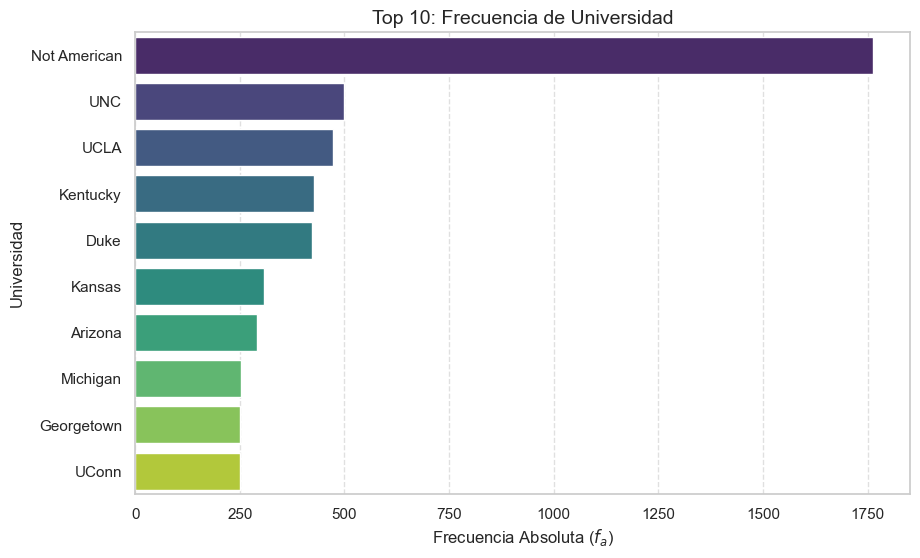

/var/folders/j6/gnqp8_1s7236st9zmm8nz4300000gn/T/ipykernel_60609/2406755213.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette='viridis')


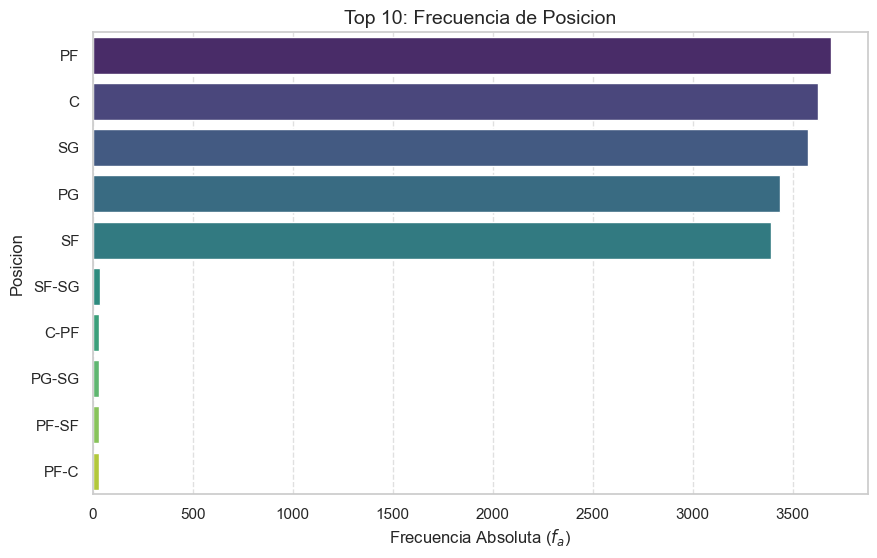

/var/folders/j6/gnqp8_1s7236st9zmm8nz4300000gn/T/ipykernel_60609/2406755213.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette='viridis')


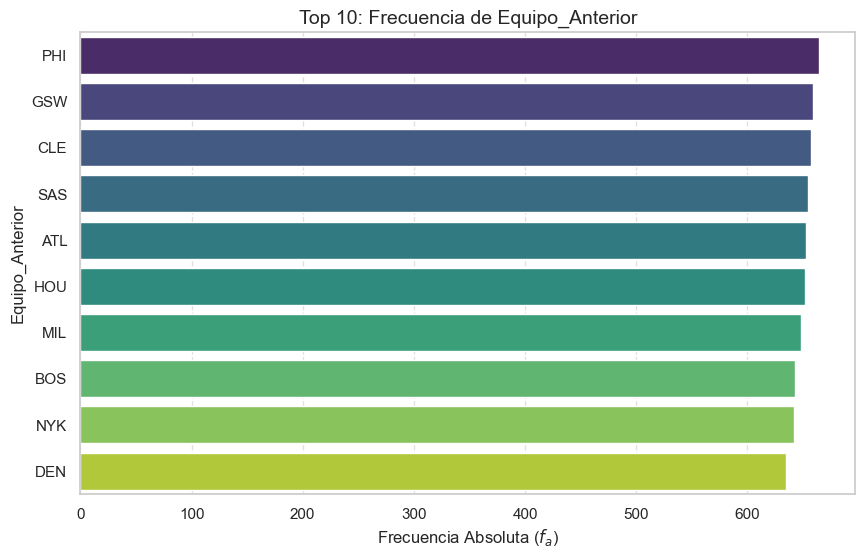

/var/folders/j6/gnqp8_1s7236st9zmm8nz4300000gn/T/ipykernel_60609/2406755213.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette='viridis')


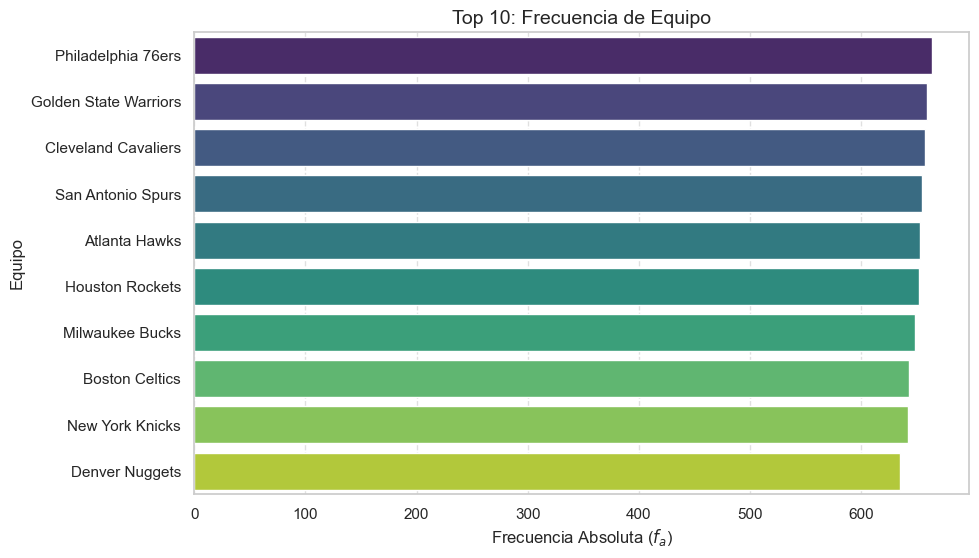

/var/folders/j6/gnqp8_1s7236st9zmm8nz4300000gn/T/ipykernel_60609/2406755213.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette='viridis')


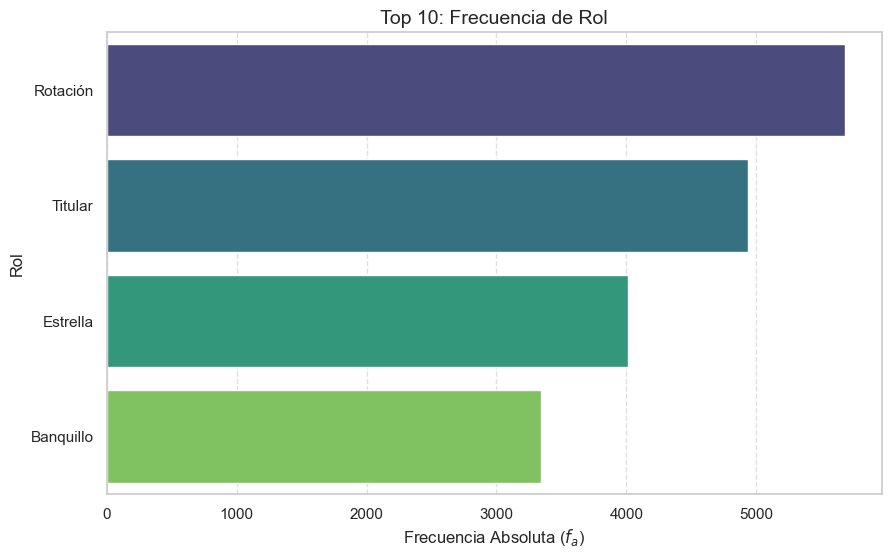

In [ ]:
for var in vars_cuali:
    plt.figure(figsize=(10, 6))
    
    top_data = df[var].value_counts().head(10)
    
    sns.barplot(x=top_data.values, y=top_data.index, palette='viridis')
    
    plt.title(f'Top 10: Frecuencia de {var}', fontsize=14)
    plt.xlabel('Frecuencia Absoluta ($f_a$)')
    plt.ylabel(var)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    
    plt.show()

In [ ]:
# No observamos que haya posibles sesgos ni que tengamos que agrupar variables para el análisis

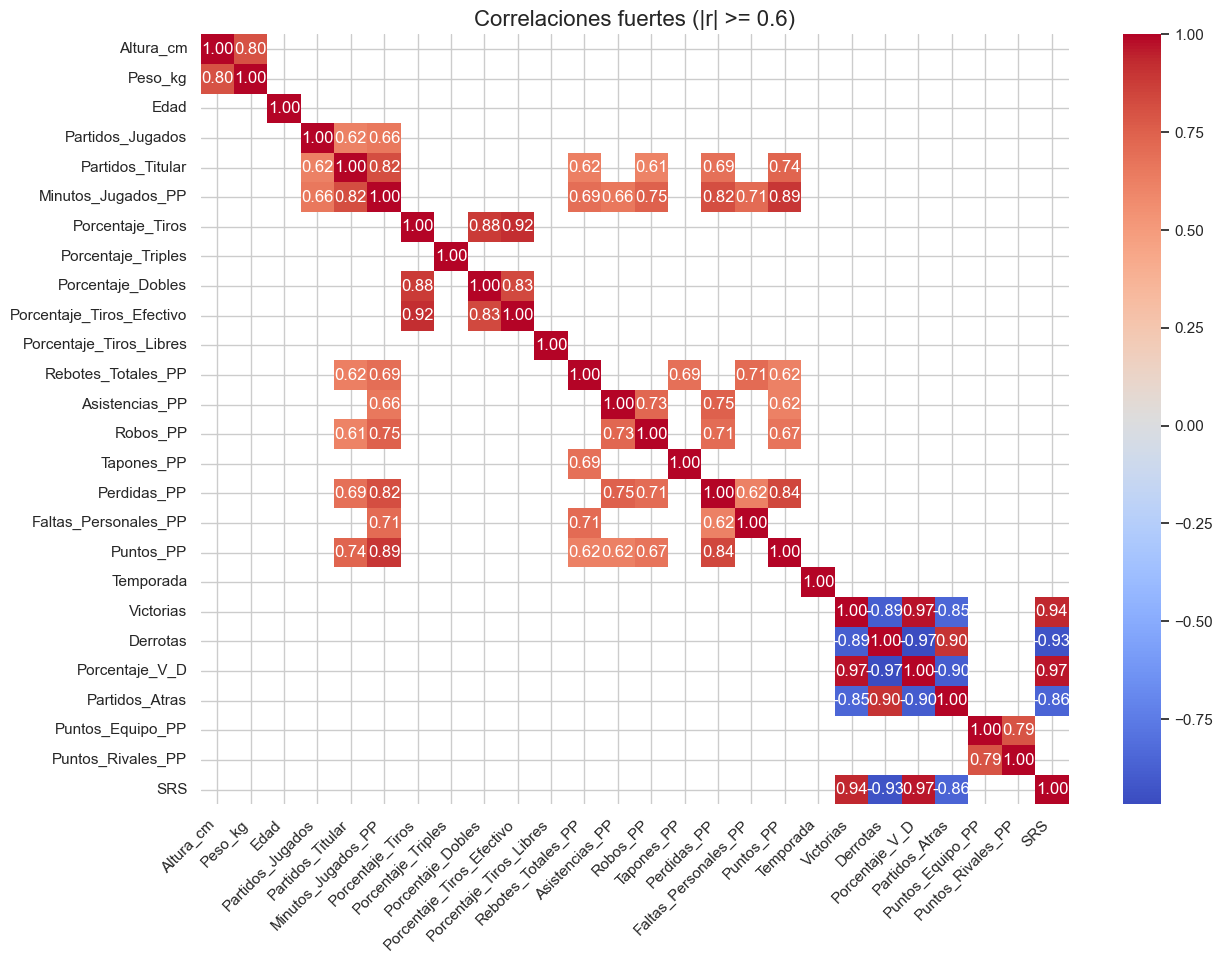

In [ ]:
# GRÁFICO DE CORRELACIONES : 

cols_analisis = ['Altura_cm', 'Peso_kg', 'Edad', 'Partidos_Jugados', 'Partidos_Titular', 'Minutos_Jugados_PP',
             'Porcentaje_Tiros', 'Porcentaje_Triples', 'Porcentaje_Dobles', 'Porcentaje_Tiros_Efectivo', 'Porcentaje_Tiros_Libres',
             'Rebotes_Totales_PP', 'Asistencias_PP', 'Robos_PP', 'Tapones_PP', 'Perdidas_PP', 'Faltas_Personales_PP', 'Puntos_PP', 'Temporada',
              'Victorias', 'Derrotas', 'Porcentaje_V_D', 'Partidos_Atras', 'Puntos_Equipo_PP', 
             'Puntos_Rivales_PP', 'SRS']
corr = df[cols_analisis].corr()

mask = (corr.abs() >= 0.6)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=~mask,          
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Correlaciones fuertes (|r| >= 0.6)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
# Tenemos un mapa de calor de correlaciones fuertes (|r| ≥ 0.6) entre variables estadísticas de jugadores. 

# Se observan varios bloques bien definidos: por un lado, variables físicas como altura y peso presentan alta correlación entre sí; por otro, métricas de rendimiento ofensivo (puntos, minutos, porcentajes de tiro) están fuertemente relacionadas, indicando que el tiempo de juego influye directamente en la producción ofensiva. 

# También aparece un grupo de variables de equipo (victorias, derrotas, porcentaje de victorias y SRS) con correlaciones casi perfectas, lo que sugiere que son medidas derivadas del mismo fenómeno. 

# En general, el gráfico evidencia alta multicolinealidad, es decir, muchas variables aportan información redundante.

# ORDENACIÓN

In [ ]:
# 1. Líderes Históricos (Top 10 en Puntos)
print("--- TOP 10 HISTÓRICO: PORCENTAJE DE TIROS ---")
top_historico = df.sort_values(by='Porcentaje_Tiros', ascending=False).head(10)
display(top_historico[['Jugador', 'Equipo', 'Temporada', 'Porcentaje_Tiros', 'Puntos_PP']])


# 2. Líderes por Temporada (
print("\n--- LÍDERES POR TEMPORADA: VICTORIAS ---")
idx_lideres_temp = df.groupby('Temporada')['Victorias'].idxmax()
lideres_por_temporada = df.loc[idx_lideres_temp]

lideres_por_temporada = lideres_por_temporada.sort_values(by='Temporada')
display(lideres_por_temporada[['Temporada', 'Jugador', 'Equipo', 'Victorias']])


# 3. El "Top 3" por Posición 
print("\n--- TOP 3 ANOTADORES POR POSICIÓN ---")
top_por_posicion = df.sort_values(['Posicion_Principal', 'Porcentaje_Tiros'], ascending=[True, False])
top_por_posicion = top_por_posicion.groupby('Posicion_Principal').head(3)
display(top_por_posicion[['Posicion_Principal', 'Jugador', 'Porcentaje_Tiros', 'Puntos_PP']])

--- TOP 10 HISTÓRICO: PORCENTAJE DE TIROS ---


,Jugador,Equipo,Temporada,Porcentaje_Tiros,Puntos_PP
7269,Jackie Butler,New York Knicks,2005.0,1.0,3.3
8692,Carl Bailey,Portland Trail Blazers,1982.0,1.0,2.0
14345,Ira Bowman,Philadelphia 76ers,2000.0,1.0,0.5
11619,Jeremy Evans,Atlanta Hawks,2018.0,1.0,2.0
16964,Eddy Curry,New York Knicks,2009.0,1.0,1.7
8770,Dajuan Wagner,Golden State Warriors,2007.0,1.0,4.0
6630,Zhou Qi,Houston Rockets,2019.0,1.0,2.0
12192,Tod Murphy,Los Angeles Clippers,1988.0,1.0,5.0
6743,Carlos Rogers,Portland Trail Blazers,1999.0,1.0,2.5
2055,Marcus Williams,San Antonio Spurs,2009.0,1.0,2.0



--- LÍDERES POR TEMPORADA: VICTORIAS ---


,Temporada,Jugador,Equipo,Victorias
7050,1980.0,Tiny Archibald,Boston Celtics,61
7063,1981.0,Tiny Archibald,Boston Celtics,62
2072,1982.0,Danny Ainge,Boston Celtics,63
17008,1983.0,Maurice Cheeks,Philadelphia 76ers,65
2099,1984.0,Danny Ainge,Boston Celtics,62
2112,1985.0,Danny Ainge,Boston Celtics,63
2125,1986.0,Danny Ainge,Boston Celtics,67
171,1987.0,Kareem Abdul-Jabbar,Los Angeles Lakers,65
183,1988.0,Kareem Abdul-Jabbar,Los Angeles Lakers,62
1930,1989.0,Mark Aguirre,Detroit Pistons,63



--- TOP 3 ANOTADORES POR POSICIÓN ---


,Posicion_Principal,Jugador,Porcentaje_Tiros,Puntos_PP
694,C,Udonis Haslem,1.0,4.0
1421,C,Dave Hoppen,1.0,1.0
1443,C,Mike Peplowski,1.0,1.8
536,PF,Kaniel Dickens,1.0,2.3
1150,PF,Tyrus Thomas,1.0,2.0
2055,PF,Marcus Williams,1.0,2.0
2922,PG,Tyson Wheeler,1.0,4.0
3695,PG,Jason Hart,1.0,2.0
6245,PG,Edmond Sumner,1.0,2.0
2598,SF,Anthony Brown,1.0,3.0


# MODELIZACIÓN

In [ ]:
def recomendar_sustituto_final(nombre_jugador, temporada_seleccionada, n_recomendaciones=5):
    temporada_buscada = int(float(temporada_seleccionada))  

    if nombre_jugador not in df['Jugador'].values:
        return f"El jugador '{nombre_jugador}' no existe en la base de datos."
    
    perfil_especifico = df[(df['Jugador'] == nombre_jugador) & (df['Temporada'] == temporada_seleccionada)]
    
    if perfil_especifico.empty:
        disponibles = sorted(df[df['Jugador'] == nombre_jugador]['Temporada'].unique().tolist())
        return f"{nombre_jugador} no jugó en {temporada_buscada}. Temporadas disponibles: {disponibles}"
    
    perfil_lesionado = perfil_especifico.iloc[0]
    pos_lesionado = perfil_lesionado['Posicion_Principal'] 
    
    df_filtrado = df[(df['Posicion_Principal'] == pos_lesionado) & (df['Temporada'] == temporada_seleccionada)].copy()
    
    pesos = {
        'Edad': 0.5, 'Partidos_Jugados': 0.7, 'Minutos_Jugados_PP': 1.2,
        'Porcentaje_Tiros_Efectivo': 1.0, 'Puntos_PP': 1.5, 'Asistencias_PP': 1.5,
        'Rebotes_Totales_PP': 1.2, 'Tapones_PP': 1.0, 'Robos_PP': 1.0
    }
    features = list(pesos.keys())
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_filtrado[features])
    
    for i, col in enumerate(features):
        X_scaled[:, i] *= pesos[col]
    
    model = NearestNeighbors(n_neighbors=n_recomendaciones + 1, metric='cosine')
    model.fit(X_scaled)
    
    idx_en_filtro = df_filtrado[df_filtrado['Jugador'] == nombre_jugador].index[0]
    pos_en_matriz = df_filtrado.index.get_loc(idx_en_filtro)
    
    distancias, indices = model.kneighbors([X_scaled[pos_en_matriz]])
    
    print(f"--- REEMPLAZO DE JUGADOR ---")
    print(f"Reemplazado: {nombre_jugador} | Temporada: {temporada_seleccionada} | Posición: {pos_lesionado}")
    return df_filtrado.iloc[indices[0][1:]][['Jugador', 'Posicion_Principal', 'Puntos_PP', 'Asistencias_PP', 'Rebotes_Totales_PP', 'Rol']]

# EJEMPLOS DE USO 
# recomendar_sustituto_final("Pau Gasol", 2010) <- Descomemtar para probar
# recomendar_sustituto_final("LeBron James", 2023) <- Descomemtar para probar

--- REEMPLAZO DE JUGADOR ---
Reemplazado: Pau Gasol | Temporada: 2010 | Posición: C


,Jugador,Posicion_Principal,Puntos_PP,Asistencias_PP,Rebotes_Totales_PP,Rol
13329,Tim Duncan,C,17.9,3.2,10.1,Estrella
12889,Al Horford,C,14.2,2.3,9.9,Estrella
10767,David Lee,C,20.2,3.6,11.7,Estrella
11273,Brook Lopez,C,18.8,2.3,8.6,Estrella
14156,Mehmet Okur,C,13.5,1.6,7.1,Titular
